# 添加记忆

聊天机器人可以使用工具来回答用户问题，但它**不记得之前交互的上下文**。这限制了它进行连贯多轮对话的能力。

LangGraph 通过持久性检查点解决了这个问题。如果您在编译图时提供一个checkpointer，并在调用图时提供一个thread_id，LangGraph 会在每一步之后自动保存状态。当您使用相同的thread_id再次调用图时，图会加载其保存的状态，允许聊天机器人从上次中断的地方继续。

我们稍后会看到，检查点比简单的聊天记忆功能强大得多——它允许您随时保存和恢复复杂状态，用于错误恢复、人工干预工作流、时间旅行交互等

In [2]:
from langchain_tavily import TavilySearch
from dotenv import load_dotenv
import os
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
import os
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langgraph.prebuilt import ToolNode, tools_condition

############### 创建 MemorySaver 检查点 ###############
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()
######################################################


class State(TypedDict):
    messages: Annotated[list, add_messages]
    
graph_builder = StateGraph(State)

# 加载 .env 文件
load_dotenv(override=True)

search_tool = TavilySearch(max_results=2,
                    tavily_api_key=os.getenv("TAVILY_API_KEY"))

tools = [search_tool]

llm = ChatOpenAI(
    model="mimo-v2-pro",
    api_key=os.getenv("XIAOMI_API_KEY"),
    base_url=os.getenv("XIAOMI_BASE_URL"),
)

# llm 绑定上工具
llm_with_tool = llm.bind_tools(tools)

def chatbot(state: State):
    return {"messages": [llm_with_tool.invoke(state["messages"])]}

graph_builder.add_node("chatbot", chatbot)



tool_node = ToolNode(tools=tools)
graph_builder.add_node("tools", tool_node)

graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition,
)
######################################################

# 每次调用工具后，都会回到聊天机器人来决定下一步
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")
graph = graph_builder.compile(checkpointer=memory)

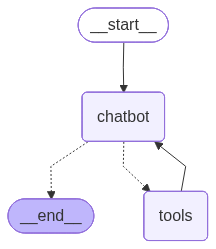

In [4]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [5]:
config = {"configurable": {"thread_id": "1"}}

In [6]:
user_input = "Hi there! My name is Will."

# The config is the **second positional argument** to stream() or invoke()!
events = graph.stream(
    {"messages": [{"role": "user", "content": user_input}]},
    config,
    stream_mode="values",
)
for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

Hi there! My name is Will.
================================== Ai Message ==================================

Hi Will! Nice to meet you! I'm MiMo-v2-pro, developed by the Xiaomi MiMo Team. I'm here to chat, help with questions, or just have a friendly conversation. What's on your mind today?


In [8]:
snapshot = graph.get_state(config)
snapshot

StateSnapshot(values={'messages': [HumanMessage(content='Hi there! My name is Will.', additional_kwargs={}, response_metadata={}, id='3967c0fc-153a-4e31-9450-234f746f3c00'), AIMessage(content="Hi Will! Nice to meet you! I'm MiMo-v2-pro, developed by the Xiaomi MiMo Team. I'm here to chat, help with questions, or just have a friendly conversation. What's on your mind today?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 93, 'prompt_tokens': 2018, 'total_tokens': 2111, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 42, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 1984}}, 'model_provider': 'openai', 'model_name': 'mimo-v2-pro', 'system_fingerprint': None, 'id': '3a9bdccbe3874ad3ad6179b803580ce9', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019df639-ff5a-7552-8e43-112ba9a40543-0', tool_calls=[], invalid_tool_calls=

In [ ]:
while True:
    try:
        user_input = input("User: ")
        if user_input.lower() in ["quit", "exit", "q"]:
            print("Goodbye!")
            break

        events = graph.stream(
            {"messages": [{"role": "user", "content": user_input}]},
            config,
            stream_mode="values")
        for event in events:
            event["messages"][-1].pretty_print()
    except BaseException as e:
        print(str(e))
        break

User:  你好啊


================================ Human Message =================================

你好啊
================================== Ai Message ==================================

你好，Will！很高兴见到你！我是小米MiMo团队开发的MiMo-v2-pro，一个拥有1T参数和1M token上下文窗口的AI助手。

有什么我可以帮助你的吗？无论是回答问题、聊天，还是其他任何事情，我都很乐意协助！😊


User:  请问你是谁？我叫nic


================================ Human Message =================================

请问你是谁？我叫nic
================================== Ai Message ==================================

你好！我是 **MiMo-v2-pro**，由**小米MiMo团队**开发的AI助手。我拥有**1T参数**和**1M token上下文窗口**，可以处理很长的对话和文档。

不过我注意到，你刚才说你叫Will，现在又说叫nic——请问哪个才是你的名字呢？还是说你有两个名字？😊


User:  哈哈哈，被你发现了。其实我叫nicolas will


...

================================ Human Message =================================

你能为我的名字写一首诗吗
================================== Ai Message ==================================

当然可以！为你写一首诗，Nicolas Will 🎶

---

**《Nicolas Will》**

N — 如夜空的星辰闪耀，
I — 是梦想在心中燃烧，
C — 像风儿自由地奔跑，
O — 如海洋般辽阔怀抱，
L — 让热爱永不曾减少，
A — 是勇气在路途照耀，
S — 愿笑容伴你到老。

W — Will的意志如山高，
I — 无惧风雨向前道，
L — 每一步都踏实牢，
L — 胜利终将为你到。

---

Nicolas Will，你的名字里藏着星辰与力量，愿你的人生如诗般精彩！✨

喜欢吗？如果你想听英文版，或者想要其他风格的诗，随时告诉我！😊


User:  啥意思呀，看不懂这一首诗呢


================================ Human Message =================================

啥意思呀，看不懂这一首诗呢
================================== Ai Message ==================================

哈哈，不好意思！让我来给你解释一下 😄

这是一首**藏头诗**，每行的第一个字连起来就是你的名字 **NICOLAS WILL**：

---

**N** — 像夜空中的星星一样闪耀
**I** — 心中燃烧着梦想的火焰
**C** — 像风一样自由自在地奔跑
**O** — 胸怀像大海一样宽广
**L** — 对生活的热爱永不减少
**A** — 勇气照亮你前行的路
**S** — 愿笑容永远陪伴你

**W** — "Will"的意志像山一样坚定
**I** — 不怕风雨，勇往直前
**L** — 每一步都走得踏实稳健
**L** — 胜利最终会来到你身边

---

简单说，就是把你的名字拆开，每个字母写一句祝福的话，连起来又能拼成你的名字！是不是稍微清楚一点了？😊

要不要我再写一首更简单直白的？


User:  藏得一点也不好，你要不直接写成英文的诗吧，每句诗的第一个单词的首字母可以做成我的名字的长都是


================================ Human Message =================================

藏得一点也不好，你要不直接写成英文的诗吧，每句诗的第一个单词的首字母可以做成我的名字的长都是
================================== Ai Message ==================================

好的！这次来一首更自然的英文藏头诗，每行首字母拼出 **NICOLAS WILL**：

---

**N**ightingales sing songs of old,
**I**n gardens where the stories unfold.
**C**ourage guides your every step,
**O**ver mountains, no regrets.
**L**ove will light your path ahead,
**A**nd chase away the doubts you'd dread.
**S**tars will shine upon your way,

**W**isdom grows with every day,
**I**n your heart it finds its stay.
**L**et your spirit soar and play,
**L**aughter greets you on your way.

---

这次藏得怎么样？😄 读起来像一首完整的诗，同时每行首字母连起来就是你的名字 **NICOLAS WILL**！

喜欢这个版本吗？
